In [1]:
print("Hello, Python")



Hello, Python


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import os
os.listdir()







['.anaconda',
 '.conda',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Diwali Sales Data (2).csv',
 'Diwali_Sales_Analysis.ipynb',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{5369f54b-8012-11f0-9fda-00001001e21c}.TM.blf',
 'NTUSER.DAT{5369f54b-8012-11f0-9fda-00001001e21c}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{5369f54b-8012-11f0-9fda-00001001e21c}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'Videos']

In [14]:
df = pd.read_csv("Diwali Sales Data (2).csv", encoding="latin1")
df.head()






,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [15]:
df.shape


(11251, 15)

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [17]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.isnull().sum()


User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [18]:
df.dropna(inplace=True)
df.shape


(11239, 13)

In [19]:
gender_sales = df.groupby('Gender')['Amount'].sum()
gender_sales


Gender
F    74335856.43
M    31913276.00
Name: Amount, dtype: float64

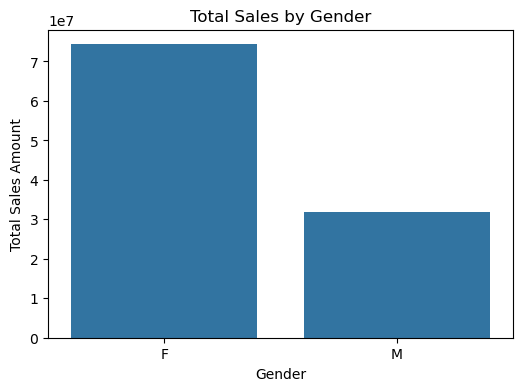

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index, y=gender_sales.values)
plt.title("Total Sales by Gender")
plt.ylabel("Total Sales Amount")
plt.xlabel("Gender")
plt.show()


In [ ]:
### Gender-wise Sales Insight

Female customers contribute higher total sales during the Diwali season
compared to male customers. This indicates that festive marketing campaigns
should focus more on female-oriented products and offers.


In [21]:
age_sales = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)
age_sales


Age Group
26-35    42613443.94
36-45    22144995.49
18-25    17240732.00
46-50     9207844.00
51-55     8261477.00
55+       4080987.00
0-17      2699653.00
Name: Amount, dtype: float64

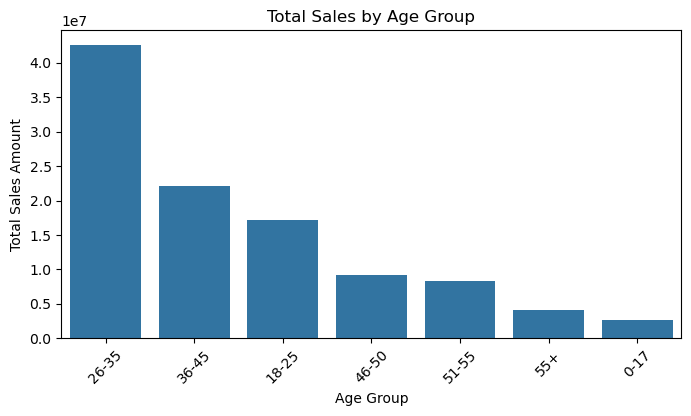

In [22]:
plt.figure(figsize=(8,4))
sns.barplot(x=age_sales.index, y=age_sales.values)
plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.show()


In [ ]:
### Age Group-wise Sales Insight

Customers aged 26–35 contribute the highest sales during the Diwali season.
Young adults show strong purchasing power, making them an ideal target
segment for festive promotions and digital marketing campaigns.


In [24]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
state_sales

State
Uttar Pradesh       19374968.00
Maharashtra         14427543.00
Karnataka           13523540.00
Delhi               11603819.45
Madhya Pradesh       8101142.00
Andhra Pradesh       8037146.99
Himachal Pradesh     4963368.00
Haryana              4220175.00
Bihar                4022757.00
Gujarat              3946082.00
Name: Amount, dtype: float64

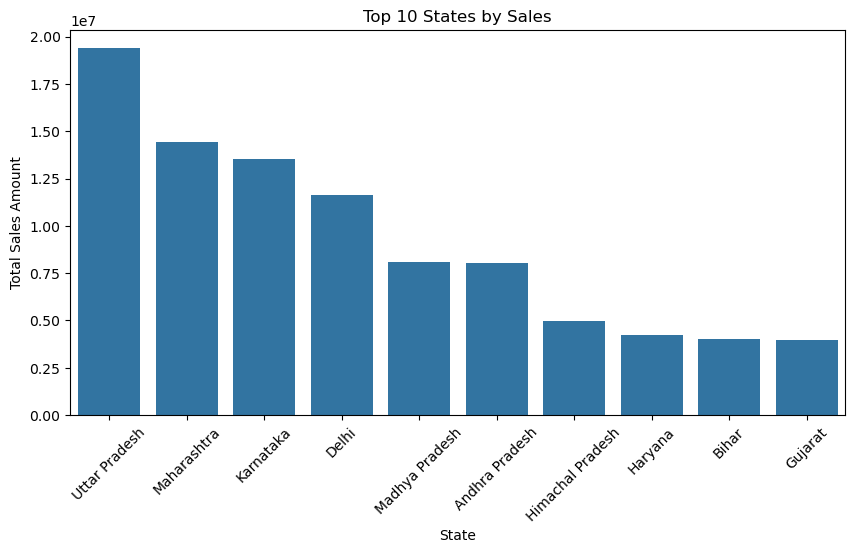

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(x=state_sales.index, y=state_sales.values)
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.show()


In [ ]:
### State-wise Sales Insight

Maharashtra, Karnataka, and Delhi are the top-performing states in terms
of Diwali sales. These regions should be prioritized for inventory planning
and targeted festive marketing campaigns.


In [26]:
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)
occupation_sales


Occupation
IT Sector          14755079.00
Healthcare         13034587.49
Aviation           12602298.00
Banking            10770610.95
Govt                8517212.00
Hospitality         6376405.00
Media               6295832.99
Automobile          5368596.00
Chemical            5297436.00
Lawyer              4981665.00
Retail              4783170.00
Food Processing     4070670.00
Construction        3597511.00
Textile             3204972.00
Agriculture         2593087.00
Name: Amount, dtype: float64

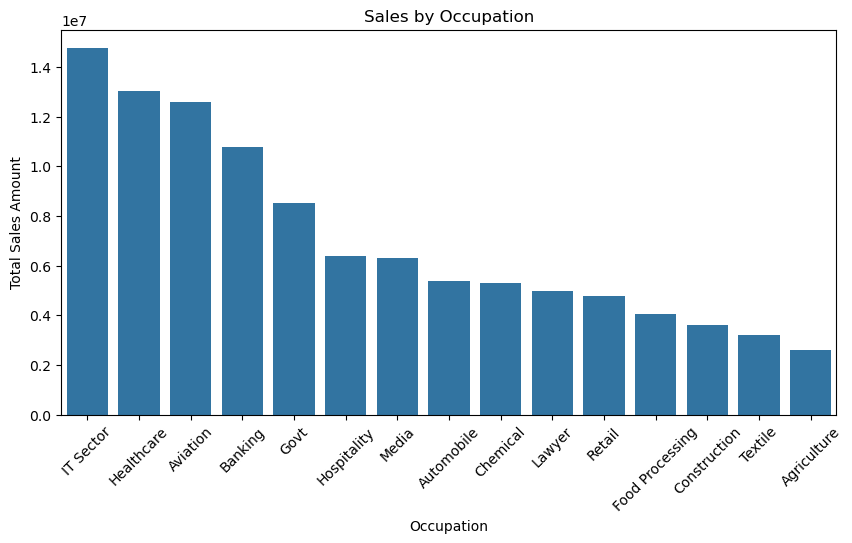

In [27]:
plt.figure(figsize=(10,5))
sns.barplot(x=occupation_sales.index, y=occupation_sales.values)
plt.title("Sales by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.show()

In [ ]:
### Occupation-wise Sales Insight

Customers working in IT, Healthcare, and Government sectors contribute
higher sales during the Diwali season. These occupations indicate higher
purchasing power and can be targeted with premium festive offers.


In [28]:
product_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
product_sales


Product_Category
Food                     33933883.50
Clothing & Apparel       16495019.00
Electronics & Gadgets    15643846.00
Footwear & Shoes         15575209.45
Furniture                 5440051.99
Games & Toys              4331694.00
Sports Products           3635933.00
Beauty                    1959484.00
Auto                      1958609.99
Stationery                1676051.50
Household items           1569337.00
Tupperware                1155642.00
Books                     1061478.00
Decor                      730360.00
Pet Care                   482277.00
Hand & Power Tools         405618.00
Veterinary                 112702.00
Office                      81936.00
Name: Amount, dtype: float64

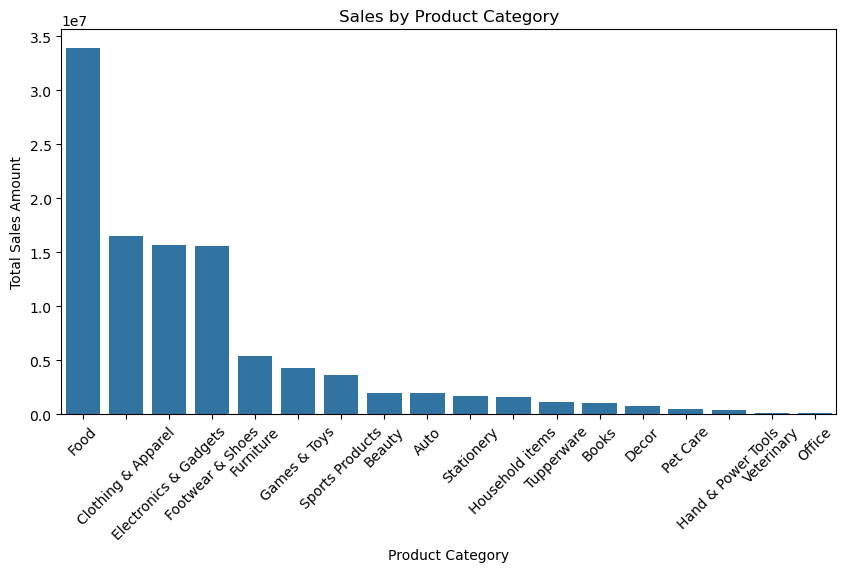

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(x=product_sales.index, y=product_sales.values)
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.show()


In [ ]:
### Product Category Sales Insight

Electronics, Clothing, and Food categories generate the highest sales
during the Diwali season. These categories should be prioritized for
discounts, promotions, and inventory planning in future festive campaigns.


In [ ]:
## Final Insights

• Female customers contribute higher Diwali sales than male customers  
• Customers aged 26–35 are the most profitable segment  
• Maharashtra, Karnataka, and Delhi are the top-performing states  
• IT, Healthcare, and Government professionals show higher spending  
• Electronics and Clothing are the best-selling product categories  

## Business Recommendations

• Focus festive marketing campaigns on young adults (26–35 age group)  
• Target high-performing states with region-specific offers  
• Promote premium products for high-spending occupations  
• Prioritize inventory for top product categories during festive seasons  
